In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mukeshmanral/graduates-admission-prediction")

print("Path to dataset files:", path)

100%|██████████| 4.25k/4.25k [00:00<00:00, 11.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mukeshmanral/graduates-admission-prediction/versions/1


In [2]:
import pandas as pd
import os

# الحصول على اسم الملف من المسار
file_name = os.listdir(path)[0]

# قراءة البيانات واستخدام الاسم data
data = pd.read_csv(os.path.join(path, file_name))

# عرض أول 5 أسطر من البيانات
data.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [3]:
data.columns = data.columns.str.strip()

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          500 non-null    int64  
 1   TOEFL Score        500 non-null    int64  
 2   University Rating  500 non-null    int64  
 3   SOP                500 non-null    float64
 4   LOR                500 non-null    float64
 5   CGPA               500 non-null    float64
 6   Research           500 non-null    int64  
 7   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 31.4 KB


In [5]:
# فصل الميزات عن الهدف
X = data.drop('Chance of Admit', axis=1)
y = data['Chance of Admit']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. إنشاء كائن الموديل
model = LinearRegression()

# 2. تدريب الموديل على البيانات المقاسة
model.fit(X_train_scaled, y_train)

# 3. التنبؤ على بيانات الاختبار (اللي ما شافها الموديل من قبل)
y_pred = model.predict(X_test_scaled)

# 4. حساب دقة الموديل
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R2 Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")

R2 Score: 0.8188
Mean Squared Error: 0.0037


In [9]:
# 1. Print the evaluation results we calculated earlier
print(f"R2 Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")

R2 Score: 0.8188
Mean Squared Error: 0.0037


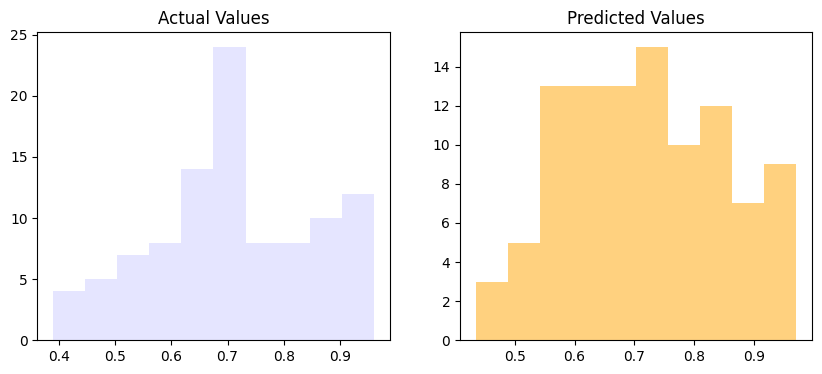

In [10]:
import matplotlib.pyplot as plt

# فتح نافذة فيها مكانين بجانب بعض (1 صف، عمودين)
plt.figure(figsize=(10, 4))

# الرسمة الأولى على اليسار (الحقيقية)
plt.subplot(1, 2, 1)
plt.hist(y_test, color='blue', alpha=0.1)
plt.title('Actual Values')

# الرسمة الثانية على اليمين (المتوقعة)
plt.subplot(1, 2, 2)
plt.hist(y_pred, color='orange', alpha=0.5)
plt.title('Predicted Values')

# عرض الرسمتين
plt.show()

In [11]:
import joblib

# حفظ النموذج باسم متناسق مع ملف graduation
joblib.dump(model, 'graduat_model.pkl')

# إذا كنتِ قد استخدمتِ Scaler لمعالجة البيانات، احفظيه أيضاً بنفس الاسم
# joblib.dump(scaler, 'graduat_scaler.pkl')

['graduat_model.pkl']